In [5]:
from sentence_transformers import SentenceTransformer
from elasticsearch import Elasticsearch

In [6]:
ELASTICSEARCH_URL = "http://localhost:9200"
INDEX_NAME = "ev-vehicles"

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

In [7]:
es_client = Elasticsearch(ELASTICSEARCH_URL)

print("Elasticsearch connected:", es_client.info())

Elasticsearch connected: {'name': '3016a6d3053d', 'cluster_name': 'docker-cluster', 'cluster_uuid': 'Ex3VVj5uSn-tVMlx6zVcpg', 'version': {'number': '8.15.0', 'build_flavor': 'default', 'build_type': 'docker', 'build_hash': '1a77947f34deddb41af25e6f0ddb8e830159c179', 'build_date': '2024-08-05T10:05:34.233336849Z', 'build_snapshot': False, 'lucene_version': '9.11.1', 'minimum_wire_compatibility_version': '7.17.0', 'minimum_index_compatibility_version': '7.0.0'}, 'tagline': 'You Know, for Search'}


In [8]:
# Check the number of documents:

document_count = es_client.count(index=INDEX_NAME)["count"]

print(f"BEV documents in Elasticsearch: {document_count:,}")

BEV documents in Elasticsearch: 1,572


In [9]:
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

print(f"Loaded embedding model: {EMBEDDING_MODEL_NAME}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loaded embedding model: sentence-transformers/all-MiniLM-L6-v2


In [10]:
SOURCE_FIELDS = [
    "id",
    "year",
    "make",
    "model",
    "vehicle_name",
    "vehicle_class",
    "drive",
    "electric_range_miles",
    "city_mpge",
    "highway_mpge",
    "combined_mpge",
    "charge_120v_hours",
    "charge_240v_hours",
    "ev_motor",
    "annual_fuel_cost_usd",
    "document_text",
]

In [11]:
def show_results(results):
    """Print retrieved BEV records in a readable format."""

    for rank, result in enumerate(results, start=1):
        source = result["_source"]

        print(f"Rank {rank}")
        print(f"Vehicle: {source.get('vehicle_name')}")
        print(f"FuelEconomy.gov ID: {source.get('id')}")
        print(f"Electric range: {source.get('electric_range_miles')} miles")
        print(f"Combined efficiency: {source.get('combined_mpge')} MPGe")
        print(f"Vehicle class: {source.get('vehicle_class')}")
        print(f"Score: {result.get('_score', 'N/A')}")
        print("-" * 80)

In [12]:
def text_search(query, number_of_results=5):
    """
    Search for BEVs using keyword and full-text matching.
    """

    response = es_client.search(
        index=INDEX_NAME,
        size=number_of_results,
        source=SOURCE_FIELDS,
        query={
            "multi_match": {
                "query": query,
                "fields": [
                    "vehicle_name^4",
                    "make^3",
                    "model^3",
                    "vehicle_class^2",
                    "document_text",
                ],
                "fuzziness": "AUTO",
            }
        },
    )

    return response["hits"]["hits"]

In [13]:
query = "Tesla Model 3"

text_results = text_search(query)

show_results(text_results)

Rank 1
Vehicle: 2022 Tesla Model 3 RWD
FuelEconomy.gov ID: 45013
Electric range: 272.0 miles
Combined efficiency: 132.0 MPGe
Vehicle class: Midsize Cars
Score: 34.119434
--------------------------------------------------------------------------------
Rank 2
Vehicle: 2023 Tesla Model 3 RWD
FuelEconomy.gov ID: 46206
Electric range: 272.0 miles
Combined efficiency: 132.0 MPGe
Vehicle class: Midsize Cars
Score: 34.119434
--------------------------------------------------------------------------------
Rank 3
Vehicle: 2024 Tesla Model 3 RWD
FuelEconomy.gov ID: 47909
Electric range: 272.0 miles
Combined efficiency: 132.0 MPGe
Vehicle class: Midsize Cars
Score: 34.119434
--------------------------------------------------------------------------------
Rank 4
Vehicle: 2026 Tesla Model 3 Performance
FuelEconomy.gov ID: 50036
Electric range: 309.0 miles
Combined efficiency: 114.0 MPGe
Vehicle class: Midsize Cars
Score: 34.119434
---------------------------------------------------------------------

In [14]:
query = "electric SUV with long range"

text_results = text_search(query)

show_results(text_results)

Rank 1
Vehicle: 2024 Hyundai Kona Electric Long Range
FuelEconomy.gov ID: 47449
Electric range: 261.0 miles
Combined efficiency: 116.0 MPGe
Vehicle class: Small Sport Utility Vehicle 2WD
Score: 33.769302
--------------------------------------------------------------------------------
Rank 2
Vehicle: 2024 Hyundai Kona Electric Standard Range
FuelEconomy.gov ID: 47831
Electric range: 200.0 miles
Combined efficiency: 118.0 MPGe
Vehicle class: Small Sport Utility Vehicle 2WD
Score: 22.522125
--------------------------------------------------------------------------------
Rank 3
Vehicle: 2025 Hyundai Kona Electric Standard Range
FuelEconomy.gov ID: 48359
Electric range: 200.0 miles
Combined efficiency: 118.0 MPGe
Vehicle class: Small Sport Utility Vehicle 2WD
Score: 22.522125
--------------------------------------------------------------------------------
Rank 4
Vehicle: 2025 Tesla Cybertruck Long Range
FuelEconomy.gov ID: 49152
Electric range: 335.0 miles
Combined efficiency: 82.0 MPGe
Veh

In [15]:
def vector_search(query, number_of_results=5):
    """
    Search for BEVs using sentence-transformer vector similarity.
    """

    query_embedding = embedding_model.encode(
        query,
        normalize_embeddings=True,
    ).tolist()

    response = es_client.search(
        index=INDEX_NAME,
        size=number_of_results,
        source=SOURCE_FIELDS,
        knn={
            "field": "embedding",
            "query_vector": query_embedding,
            "k": number_of_results,
            "num_candidates": 100,
        },
    )

    return response["hits"]["hits"]

In [16]:
query = "Which fully electric cars can travel the farthest before recharging?"

vector_results = vector_search(query)

show_results(vector_results)

Rank 1
Vehicle: 2024 Dodge Charger 2-Dr Daytona R/T AWD 20in Nexen
FuelEconomy.gov ID: 48784
Electric range: 308.0 miles
Combined efficiency: 98.0 MPGe
Vehicle class: Large Cars
Score: 0.78355956
--------------------------------------------------------------------------------
Rank 2
Vehicle: 2025 Mercedes-Benz EQE 500 4matic (SUV)
FuelEconomy.gov ID: 48391
Electric range: 264.0 miles
Combined efficiency: 81.0 MPGe
Vehicle class: Midsize Station Wagons
Score: 0.7817862
--------------------------------------------------------------------------------
Rank 3
Vehicle: 2024 Dodge Charger 2-Dr Daytona R/T AWD 20in Goodyear
FuelEconomy.gov ID: 48783
Electric range: 268.0 miles
Combined efficiency: 85.0 MPGe
Vehicle class: Large Cars
Score: 0.7814834
--------------------------------------------------------------------------------
Rank 4
Vehicle: 2026 Mercedes-Benz AMG EQE 4matic Plus (SUV)
FuelEconomy.gov ID: 49686
Electric range: 230.0 miles
Combined efficiency: 74.0 MPGe
Vehicle class: Midsiz

In [17]:
query = "Show efficient electric cars that use little energy"

vector_results = vector_search(query)

show_results(vector_results)

Rank 1
Vehicle: 2026 Porsche Macan 4S Electric
FuelEconomy.gov ID: 50295
Electric range: 290.0 miles
Combined efficiency: 92.0 MPGe
Vehicle class: Small Sport Utility Vehicle 4WD
Score: 0.7790029
--------------------------------------------------------------------------------
Rank 2
Vehicle: 2024 Porsche Macan 4 Electric
FuelEconomy.gov ID: 48793
Electric range: 308.0 miles
Combined efficiency: 98.0 MPGe
Vehicle class: Small Sport Utility Vehicle 4WD
Score: 0.775475
--------------------------------------------------------------------------------
Rank 3
Vehicle: 2014 Fiat 500e
FuelEconomy.gov ID: 34392
Electric range: 87.0 miles
Combined efficiency: 116.0 MPGe
Vehicle class: Minicompact Cars
Score: 0.774153
--------------------------------------------------------------------------------
Rank 4
Vehicle: 2025 Porsche Macan 4S Electric
FuelEconomy.gov ID: 48728
Electric range: 288.0 miles
Combined efficiency: 91.0 MPGe
Vehicle class: Small Sport Utility Vehicle 4WD
Score: 0.773237
--------

# Compare text and vector results

In [18]:
query = "Which electric cars can drive the farthest without charging?"

In [19]:
print("TEXT SEARCH RESULTS")
print("=" * 80)

text_results = text_search(query)
show_results(text_results)

TEXT SEARCH RESULTS
Rank 1
Vehicle: 2011 smart fortwo electric drive cabriolet
FuelEconomy.gov ID: 31064
Electric range: 63.0 miles
Combined efficiency: 87.0 MPGe
Vehicle class: Two Seaters
Score: 30.487679
--------------------------------------------------------------------------------
Rank 2
Vehicle: 2011 smart fortwo electric drive coupe
FuelEconomy.gov ID: 31065
Electric range: 63.0 miles
Combined efficiency: 87.0 MPGe
Vehicle class: Two Seaters
Score: 30.487679
--------------------------------------------------------------------------------
Rank 3
Vehicle: 2013 smart fortwo electric drive convertible
FuelEconomy.gov ID: 33305
Electric range: 68.0 miles
Combined efficiency: 107.0 MPGe
Vehicle class: Two Seaters
Score: 30.487679
--------------------------------------------------------------------------------
Rank 4
Vehicle: 2013 smart fortwo electric drive coupe
FuelEconomy.gov ID: 33306
Electric range: 68.0 miles
Combined efficiency: 107.0 MPGe
Vehicle class: Two Seaters
Score: 30.

In [20]:
print("VECTOR SEARCH RESULTS")
print("=" * 80)

vector_results = vector_search(query)
show_results(vector_results)

VECTOR SEARCH RESULTS
Rank 1
Vehicle: 2025 Tesla Model 3 Long Range RWD-I (19in wheels)
FuelEconomy.gov ID: 49154
Electric range: 346.0 miles
Combined efficiency: 131.0 MPGe
Vehicle class: Midsize Cars
Score: 0.7886565
--------------------------------------------------------------------------------
Rank 2
Vehicle: 2024 Dodge Charger 2-Dr Daytona R/T AWD 20in Nexen
FuelEconomy.gov ID: 48784
Electric range: 308.0 miles
Combined efficiency: 98.0 MPGe
Vehicle class: Large Cars
Score: 0.78272796
--------------------------------------------------------------------------------
Rank 3
Vehicle: 2025 Mercedes-Benz EQE 500 4matic (SUV)
FuelEconomy.gov ID: 48391
Electric range: 264.0 miles
Combined efficiency: 81.0 MPGe
Vehicle class: Midsize Station Wagons
Score: 0.7827122
--------------------------------------------------------------------------------
Rank 4
Vehicle: 2024 Dodge Charger 2-Dr Daytona R/T AWD 20in Goodyear
FuelEconomy.gov ID: 48783
Electric range: 268.0 miles
Combined efficiency: 8

# Build hybrid search with Reciprocal Rank Fusion

In [21]:
# Build hybrid search with Reciprocal Rank Fusion


def hybrid_search(
    query,
    number_of_results=5,
    candidate_results=20,
    rrf_constant=60,
):
    """
    Combine text and vector results using Reciprocal Rank Fusion.
    """

    text_results = text_search(
        query,
        number_of_results=candidate_results,
    )

    vector_results = vector_search(
        query,
        number_of_results=candidate_results,
    )

    combined_results = {}

    # Add scores based on text-search ranking
    for rank, result in enumerate(text_results, start=1):
        document_id = result["_id"]

        if document_id not in combined_results:
            combined_results[document_id] = {
                "_source": result["_source"],
                "_score": 0,
                "text_rank": None,
                "vector_rank": None,
            }

        combined_results[document_id]["_score"] += 1 / (
            rrf_constant + rank
        )

        combined_results[document_id]["text_rank"] = rank

    # Add scores based on vector-search ranking
    for rank, result in enumerate(vector_results, start=1):
        document_id = result["_id"]

        if document_id not in combined_results:
            combined_results[document_id] = {
                "_source": result["_source"],
                "_score": 0,
                "text_rank": None,
                "vector_rank": None,
            }

        combined_results[document_id]["_score"] += 1 / (
            rrf_constant + rank
        )

        combined_results[document_id]["vector_rank"] = rank

    ranked_results = sorted(
        combined_results.values(),
        key=lambda result: result["_score"],
        reverse=True,
    )

    return ranked_results[:number_of_results]

In [22]:
query = "Which battery electric vehicles have the longest driving range?"

hybrid_results = hybrid_search(query)

show_results(hybrid_results)

Rank 1
Vehicle: 2024 Hyundai Kona Electric Long Range
FuelEconomy.gov ID: 47449
Electric range: 261.0 miles
Combined efficiency: 116.0 MPGe
Vehicle class: Small Sport Utility Vehicle 2WD
Score: 0.01639344262295082
--------------------------------------------------------------------------------
Rank 2
Vehicle: 2020 Tesla Model S Long Range
FuelEconomy.gov ID: 42282
Electric range: 373.0 miles
Combined efficiency: 111.0 MPGe
Vehicle class: Large Cars
Score: 0.01639344262295082
--------------------------------------------------------------------------------
Rank 3
Vehicle: 2024 Hyundai Kona Electric Standard Range
FuelEconomy.gov ID: 47831
Electric range: 200.0 miles
Combined efficiency: 118.0 MPGe
Vehicle class: Small Sport Utility Vehicle 2WD
Score: 0.016129032258064516
--------------------------------------------------------------------------------
Rank 4
Vehicle: 2020 Tesla Model S Long Range Plus
FuelEconomy.gov ID: 42755
Electric range: 402.0 miles
Combined efficiency: 117.0 MPGe
Ve

In [23]:
query = "What are the specifications of the Tesla Model Y?"

hybrid_results = hybrid_search(query)

show_results(hybrid_results)

Rank 1
Vehicle: 2022 Tesla Model Y RWD
FuelEconomy.gov ID: 45017
Electric range: 244.0 miles
Combined efficiency: 129.0 MPGe
Vehicle class: Small Sport Utility Vehicle 2WD
Score: 0.03278688524590164
--------------------------------------------------------------------------------
Rank 2
Vehicle: 2024 Tesla Model Y RWD
FuelEconomy.gov ID: 48476
Electric range: 260.0 miles
Combined efficiency: 120.0 MPGe
Vehicle class: Small Sport Utility Vehicle 2WD
Score: 0.031009615384615385
--------------------------------------------------------------------------------
Rank 3
Vehicle: 2023 Tesla Model Y Performance AWD
FuelEconomy.gov ID: 46213
Electric range: 303.0 miles
Combined efficiency: 111.0 MPGe
Vehicle class: Small Sport Utility Vehicle 4WD
Score: 0.03057889822595705
--------------------------------------------------------------------------------
Rank 4
Vehicle: 2023 Tesla Model Y AWD
FuelEconomy.gov ID: 46211
Electric range: 279.0 miles
Combined efficiency: 123.0 MPGe
Vehicle class: Small S

In [24]:
query = "Which electric cars have high MPGe efficiency?"

hybrid_results = hybrid_search(query)

show_results(hybrid_results)

Rank 1
Vehicle: 1998 Chevrolet S10 Electric
FuelEconomy.gov ID: 30976
Electric range: 33.0 miles
Combined efficiency: 55.0 MPGe
Vehicle class: Small Pickup Trucks 2WD
Score: 0.01639344262295082
--------------------------------------------------------------------------------
Rank 2
Vehicle: 2026 Lucid Air Pure RWD with 19 inch wheels
FuelEconomy.gov ID: 49969
Electric range: 420.0 miles
Combined efficiency: 146.0 MPGe
Vehicle class: Large Cars
Score: 0.01639344262295082
--------------------------------------------------------------------------------
Rank 3
Vehicle: 1998 Chevrolet S10 Electric
FuelEconomy.gov ID: 30977
Electric range: 72.0 miles
Combined efficiency: 28.0 MPGe
Vehicle class: Small Pickup Trucks 2WD
Score: 0.016129032258064516
--------------------------------------------------------------------------------
Rank 4
Vehicle: 2027 Mercedes-Benz EQE 320 Plus (SUV)
FuelEconomy.gov ID: 50661
Electric range: 302.0 miles
Combined efficiency: 93.0 MPGe
Vehicle class: Midsize Station

In [25]:

"""
Text-search rank: 1
Vector-search rank: 2

This means the vehicle was considered relevant by both retrieval approaches, which is generally a strong sign.
"""



query = "electric SUV with long range"

hybrid_results = hybrid_search(query)

for rank, result in enumerate(hybrid_results, start=1):
    source = result["_source"]

    print(f"Final hybrid rank: {rank}")
    print(f"Vehicle: {source['vehicle_name']}")
    print(f"RRF score: {result['_score']:.4f}")
    print(f"Text-search rank: {result['text_rank']}")
    print(f"Vector-search rank: {result['vector_rank']}")
    print("-" * 80)

Final hybrid rank: 1
Vehicle: 2024 Hyundai Kona Electric Long Range
RRF score: 0.0164
Text-search rank: 1
Vector-search rank: None
--------------------------------------------------------------------------------
Final hybrid rank: 2
Vehicle: 2024 Rivian R1S All-Terrain Quad Large (20 inch)
RRF score: 0.0164
Text-search rank: None
Vector-search rank: 1
--------------------------------------------------------------------------------
Final hybrid rank: 3
Vehicle: 2024 Hyundai Kona Electric Standard Range
RRF score: 0.0161
Text-search rank: 2
Vector-search rank: None
--------------------------------------------------------------------------------
Final hybrid rank: 4
Vehicle: 2024 Rivian R1T All-Terrain Quad Large (20in)
RRF score: 0.0161
Text-search rank: None
Vector-search rank: 2
--------------------------------------------------------------------------------
Final hybrid rank: 5
Vehicle: 2025 Hyundai Kona Electric Standard Range
RRF score: 0.0159
Text-search rank: 3
Vector-search rank:

In [26]:
test_questions = [
    "What is the range of the Tesla Model 3?",
    "Which battery electric vehicles have the longest driving range?",
    "Show electric SUVs with good range.",
    "Which fully electric cars are the most efficient?",
    "What EVs have the shortest Level 2 charging time?",
    "Show electric vehicles made by Nissan.",
    "Which electric cars have all-wheel drive?",
    "What electric cars are in the small SUV class?",
]

In [27]:
query = test_questions[2]

print("QUESTION:")
print(query)

print("\nTEXT SEARCH")
show_results(text_search(query))

print("\nVECTOR SEARCH")
show_results(vector_search(query))

print("\nHYBRID SEARCH")
show_results(hybrid_search(query))

QUESTION:
Show electric SUVs with good range.

TEXT SEARCH
Rank 1
Vehicle: 2024 Hyundai Kona Electric Long Range
FuelEconomy.gov ID: 47449
Electric range: 261.0 miles
Combined efficiency: 116.0 MPGe
Vehicle class: Small Sport Utility Vehicle 2WD
Score: 22.522125
--------------------------------------------------------------------------------
Rank 2
Vehicle: 2024 Hyundai Kona Electric Standard Range
FuelEconomy.gov ID: 47831
Electric range: 200.0 miles
Combined efficiency: 118.0 MPGe
Vehicle class: Small Sport Utility Vehicle 2WD
Score: 22.522125
--------------------------------------------------------------------------------
Rank 3
Vehicle: 2025 Hyundai Kona Electric Standard Range
FuelEconomy.gov ID: 48359
Electric range: 200.0 miles
Combined efficiency: 118.0 MPGe
Vehicle class: Small Sport Utility Vehicle 2WD
Score: 22.522125
--------------------------------------------------------------------------------
Rank 4
Vehicle: 1998 Chevrolet S10 Electric
FuelEconomy.gov ID: 30976
Electric

In [28]:
import os
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv
from openai import OpenAI

In [29]:
PROCESSED_DATA_PATH = Path("../data/processed/bev_vehicles.csv")
EVALUATION_DIR = Path("../data/evaluation")

EVALUATION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

GROUND_TRUTH_PATH = EVALUATION_DIR / "retrieval_ground_truth.csv"
RETRIEVAL_RESULTS_PATH = EVALUATION_DIR / "retrieval_results.csv"
RETRIEVAL_SUMMARY_PATH = EVALUATION_DIR / "retrieval_summary.csv"

In [30]:
bev_df = pd.read_csv(
    PROCESSED_DATA_PATH,
    dtype={"id": str},
)

print("Number of BEV records:", len(bev_df))

bev_df.head()

Number of BEV records: 1572


,id,year,make,model,vehicle_class,drive,transmission,electric_range_miles,city_mpge,highway_mpge,combined_mpge,charge_120v_hours,charge_240v_hours,ev_motor,annual_energy_cost_usd,tailpipe_co2_gpm,vehicle_type,fuel_type,vehicle_name,document_text
0,16423,2000,Nissan,Altra EV,Midsize Station Wagons,NaN,NaN,90.0,81.0,91.0,85.0,NaN,NaN,62 KW AC Induction,900.0,0.0,Battery Electric Vehicle (BEV),Electricity,2000 Nissan Altra EV,Vehicle: 2000 Nissan Altra EV\nFuelEconomy.gov...
1,16424,2000,Toyota,RAV4 EV,Sport Utility Vehicle - 2WD,2-Wheel Drive,NaN,88.0,81.0,64.0,72.0,NaN,NaN,50 KW DC,1050.0,0.0,Battery Electric Vehicle (BEV),Electricity,2000 Toyota RAV4 EV,Vehicle: 2000 Toyota RAV4 EV\nFuelEconomy.gov ...
2,17328,2001,Toyota,RAV4 EV,Sport Utility Vehicle - 2WD,2-Wheel Drive,NaN,88.0,81.0,64.0,72.0,NaN,NaN,50 KW DC,1050.0,0.0,Battery Electric Vehicle (BEV),Electricity,2001 Toyota RAV4 EV,Vehicle: 2001 Toyota RAV4 EV\nFuelEconomy.gov ...
3,17329,2001,Ford,Th!nk,Two Seaters,NaN,NaN,29.0,74.0,58.0,65.0,NaN,NaN,27 KW AC Induction,1150.0,0.0,Battery Electric Vehicle (BEV),Electricity,2001 Ford Th!nk,Vehicle: 2001 Ford Th!nk\nFuelEconomy.gov vehi...
4,17330,2001,Ford,Explorer USPS Electric,Sport Utility Vehicle - 2WD,2-Wheel Drive,NaN,38.0,45.0,33.0,39.0,NaN,NaN,67 KW AC Induction,1950.0,0.0,Battery Electric Vehicle (BEV),Electricity,2001 Ford Explorer USPS Electric,Vehicle: 2001 Ford Explorer USPS Electric\nFue...


In [31]:
bev_df[
    [
        "id",
        "vehicle_name",
        "electric_range_miles",
        "combined_mpge",
        "charge_240v_hours",
    ]
].head(10)

,id,vehicle_name,electric_range_miles,combined_mpge,charge_240v_hours
0,16423,2000 Nissan Altra EV,90.0,85.0,NaN
1,16424,2000 Toyota RAV4 EV,88.0,72.0,NaN
2,17328,2001 Toyota RAV4 EV,88.0,72.0,NaN
3,17329,2001 Ford Th!nk,29.0,65.0,NaN
4,17330,2001 Ford Explorer USPS Electric,38.0,39.0,NaN
5,17331,2001 Nissan Hyper-Mini,33.0,75.0,NaN
6,18290,2002 Toyota RAV4 EV,95.0,78.0,NaN
7,18291,2002 Ford Explorer USPS Electric,38.0,39.0,NaN
8,19296,2003 Toyota RAV4 EV,95.0,78.0,NaN
9,30965,2001 Ford Ranger Pickup 2WD,50.0,58.0,NaN


In [32]:
load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
OPENAI_MODEL = os.getenv("OPENAI_CHAT_MODEL", "gpt-4o-mini")

if not OPENAI_API_KEY:
    raise ValueError(
        "OPENAI_API_KEY was not found. "
        "Check your .env file."
    )

openai_client = OpenAI(api_key=OPENAI_API_KEY)

print("OpenAI is ready.")
print("Model:", OPENAI_MODEL)

OpenAI is ready.
Model: gpt-5.4-mini


In [35]:
# We choose vehicles with range, MPGe, and charging-time values available. This gives OpenAI enough information to create useful questions.

evaluation_candidates = bev_df[
    bev_df["electric_range_miles"].notna()
    & bev_df["combined_mpge"].notna()
    & bev_df["charge_240v_hours"].notna()
].copy()

In [36]:
evaluation_candidates = evaluation_candidates.drop_duplicates(
    subset=["vehicle_name"]
)

print("Possible vehicles for evaluation:", len(evaluation_candidates))

Possible vehicles for evaluation: 1545


In [37]:
NUMBER_OF_QUESTIONS = 15

selected_vehicles = evaluation_candidates.sample(
    n=NUMBER_OF_QUESTIONS,
    random_state=42,
).reset_index(drop=True)

selected_vehicles[
    [
        "id",
        "vehicle_name",
        "electric_range_miles",
        "combined_mpge",
        "charge_240v_hours",
    ]
]

,id,vehicle_name,electric_range_miles,combined_mpge,charge_240v_hours
0,50653,2027 Lucid Gravity GT w/20F21R wheels (3R),437.0,104.0,9.5
1,46972,2024 MINI Cooper SE Hardtop 2 door,114.0,110.0,4.0
2,49979,2026 Rolls-Royce Spectre (22 inch Wheels),277.0,77.0,10.0
3,46957,2024 Hyundai Ioniq 6 Long range RWD (18 inch W...,361.0,140.0,7.5
4,49616,2026 BMW i5 xDrive40 Sedan (19 inch Wheels),278.0,98.0,8.0
5,48363,2025 Hyundai Ioniq 6 RWD (20 inch Wheels),291.0,111.0,7.5
6,50672,2027 Rivian R1S Premium Long Range (20in),380.0,80.0,15.0
7,50663,2027 Mercedes-Benz EQS 550 4matic (SUV),317.0,80.0,14.0
8,49725,2026 Rivian R1S All-Terrain Dual Large Plus (2...,292.0,72.0,12.0
9,49696,2026 Rivian R1T Performance Dual Max (20in),380.0,80.0,15.0


In [38]:
def create_question(vehicle_name, document_text, topic):
    """
    Create one factual question about one BEV record.
    """

    prompt = f"""
        Create one short question about this battery electric vehicle.

        Rules:
        - Use only information from the vehicle record.
        - Mention the exact vehicle name: {vehicle_name}
        - The question topic must be: {topic}
        - Do not provide the answer.
        - Do not add explanations.
        - Return only one question.

        Vehicle record:
        {document_text}
    """.strip()

    response = openai_client.chat.completions.create(
        model=OPENAI_MODEL,
        temperature=0,
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
    )

    return response.choices[0].message.content.strip()

In [39]:
question_topics = [
    "electric driving range",
    "combined MPGe efficiency",
    "240V Level 2 charging time",
]

In [40]:
evaluation_rows = []

for index, row in selected_vehicles.iterrows():

    topic = question_topics[index % len(question_topics)]

    question = create_question(
        vehicle_name=row["vehicle_name"],
        document_text=row["document_text"],
        topic=topic,
    )

    evaluation_rows.append(
        {
            "question": question,
            "correct_vehicle_id": row["id"],
            "correct_vehicle_name": row["vehicle_name"],
            "topic": topic,
        }
    )

ground_truth_df = pd.DataFrame(evaluation_rows)

ground_truth_df.to_csv(
    GROUND_TRUTH_PATH,
    index=False,
)

print("Ground truth saved to:", GROUND_TRUTH_PATH)

Ground truth saved to: ../data/evaluation/retrieval_ground_truth.csv


In [41]:
for _, row in ground_truth_df.iterrows():

    vehicle_id = row["correct_vehicle_id"]

    vehicle = bev_df[
        bev_df["id"] == vehicle_id
    ].iloc[0]

    print("QUESTION:")
    print(row["question"])
    print()

    print("CORRECT VEHICLE:")
    print(vehicle["vehicle_name"])
    print()

    print("VEHICLE RECORD:")
    print(vehicle["document_text"])
    print()

    print("=" * 100)

QUESTION:
What is the electric driving range of the 2027 Lucid Gravity GT w/20F21R wheels (3R)?

CORRECT VEHICLE:
2027 Lucid Gravity GT w/20F21R wheels (3R)

VEHICLE RECORD:
Vehicle: 2027 Lucid Gravity GT w/20F21R wheels (3R)
FuelEconomy.gov vehicle ID: 50653
Vehicle type: Battery Electric Vehicle (BEV)
Vehicle class: Standard Sport Utility Vehicle 4WD
Drive: All-Wheel Drive
Transmission: Automatic (A1)
Electric range: 437.0 miles
City efficiency: 108.0 MPGe
Highway efficiency: 100.0 MPGe
Combined efficiency: 104.0 MPGe
120V charging time: nan hours
240V charging time: 9.5 hours
Electric motor: 170 and 448 kW ACPM
Annual energy cost: 750.0 USD
Tailpipe CO2 emissions: 0.0 grams per mile
Source: U.S. Department of Energy FuelEconomy.gov dataset.

QUESTION:
What is the combined MPGe efficiency of the 2024 MINI Cooper SE Hardtop 2 door?

CORRECT VEHICLE:
2024 MINI Cooper SE Hardtop 2 door

VEHICLE RECORD:
Vehicle: 2024 MINI Cooper SE Hardtop 2 door
FuelEconomy.gov vehicle ID: 46972
Vehicle

In [42]:
TOP_K = 5

In [43]:
def evaluate_one_question(
    question,
    correct_vehicle_id,
    search_function,
    method_name,
):
    """
    Evaluate one question with one retrieval method.
    """

    search_results = search_function(
        question,
        number_of_results=TOP_K,
    )

    correct_vehicle_id = str(correct_vehicle_id)

    correct_rank = 0

    for rank, result in enumerate(search_results, start=1):

        retrieved_vehicle_id = str(
            result["_source"]["id"]
        )

        if retrieved_vehicle_id == correct_vehicle_id:
            correct_rank = rank
            break

    # Hit Rate: 1 if correct vehicle was found, otherwise 0
    if correct_rank > 0:
        hit = 1
    else:
        hit = 0

    # Reciprocal rank: 1/rank if found, otherwise 0
    if correct_rank > 0:
        reciprocal_rank = 1 / correct_rank
    else:
        reciprocal_rank = 0

    retrieved_vehicle_ids = []

    for result in search_results:
        retrieved_vehicle_ids.append(
            str(result["_source"]["id"])
        )

    return {
        "method": method_name,
        "question": question,
        "correct_vehicle_id": correct_vehicle_id,
        "correct_rank": correct_rank,
        "hit": hit,
        "reciprocal_rank": reciprocal_rank,
        "retrieved_vehicle_ids": " | ".join(
            retrieved_vehicle_ids
        ),
    }

In [44]:
def evaluate_retrieval_method(
    ground_truth_df,
    search_function,
    method_name,
):
    """
    Evaluate one retrieval method using every question.
    """

    results = []

    for _, row in ground_truth_df.iterrows():

        evaluation_result = evaluate_one_question(
            question=row["question"],
            correct_vehicle_id=row["correct_vehicle_id"],
            search_function=search_function,
            method_name=method_name,
        )

        results.append(evaluation_result)

    return pd.DataFrame(results)

In [45]:
text_results_df = evaluate_retrieval_method(
    ground_truth_df=ground_truth_df,
    search_function=text_search,
    method_name="Text search",
)

text_results_df

,method,question,correct_vehicle_id,correct_rank,hit,reciprocal_rank,retrieved_vehicle_ids
0,Text search,What is the electric driving range of the 2027...,50653,1,1,1.0,50653 | 49111 | 50029 | 50655 | 50657
1,Text search,What is the combined MPGe efficiency of the 20...,46972,1,1,1.0,46972 | 42508 | 42634 | 43953 | 45330
2,Text search,What is the 240V Level 2 charging time for the...,49979,1,1,1.0,49979 | 47480 | 48442 | 49977 | 47478
3,Text search,What is the electric driving range of the 2024...,46957,1,1,1.0,46957 | 46622 | 46955 | 46620 | 46958
4,Text search,What is the combined MPGe efficiency of the 20...,49616,1,1,1.0,49616 | 48322 | 50603 | 49613 | 46923
5,Text search,What is the 240V Level 2 charging time for the...,48363,1,1,1.0,48363 | 48365 | 46623 | 46958 | 48362
6,Text search,What is the electric driving range of the 2027...,50672,1,1,1.0,50672 | 50673 | 50684 | 50671 | 50685
7,Text search,What is the combined MPGe efficiency of the 20...,50663,1,1,1.0,50663 | 49689 | 46010 | 46012 | 47850
8,Text search,What is the 240V Level 2 charging time for the...,49725,1,1,1.0,49725 | 48428 | 49700 | 49727 | 48416
9,Text search,What is the electric driving range of the 2026...,49696,1,1,1.0,49696 | 48426 | 49697 | 49721 | 47878


In [46]:
text_hit_rate = text_results_df["hit"].mean()
text_mrr = text_results_df["reciprocal_rank"].mean()

print(f"Text search Hit Rate@{TOP_K}: {text_hit_rate:.2%}")
print(f"Text search MRR@{TOP_K}: {text_mrr:.3f}")

Text search Hit Rate@5: 100.00%
Text search MRR@5: 1.000


In [47]:
vector_results_df = evaluate_retrieval_method(
    ground_truth_df=ground_truth_df,
    search_function=vector_search,
    method_name="Vector search",
)

vector_results_df

,method,question,correct_vehicle_id,correct_rank,hit,reciprocal_rank,retrieved_vehicle_ids
0,Vector search,What is the electric driving range of the 2027...,50653,1,1,1.000000,50653 | 49675 | 50029 | 50658 | 49111
1,Vector search,What is the combined MPGe efficiency of the 20...,46972,2,1,0.500000,42634 | 46972 | 43953 | 42508 | 45330
2,Vector search,What is the 240V Level 2 charging time for the...,49979,0,0,0.000000,48442 | 48443 | 49980 | 47481 | 47480
3,Vector search,What is the electric driving range of the 2024...,46957,1,1,1.000000,46957 | 46622 | 46958 | 46623 | 46959
4,Vector search,What is the combined MPGe efficiency of the 20...,49616,0,0,0.000000,48335 | 50195 | 45994 | 48323 | 50193
5,Vector search,What is the 240V Level 2 charging time for the...,48363,0,0,0.000000,48362 | 46623 | 46957 | 46958 | 46622
6,Vector search,What is the electric driving range of the 2027...,50672,3,1,0.333333,50671 | 50673 | 50672 | 50683 | 50684
7,Vector search,What is the combined MPGe efficiency of the 20...,50663,1,1,1.000000,50663 | 49689 | 48396 | 50662 | 47850
8,Vector search,What is the 240V Level 2 charging time for the...,49725,0,0,0.000000,49714 | 49698 | 49739 | 49720 | 47889
9,Vector search,What is the electric driving range of the 2026...,49696,2,1,0.500000,49721 | 49696 | 49697 | 48438 | 49704


In [48]:
vector_hit_rate = vector_results_df["hit"].mean()
vector_mrr = vector_results_df["reciprocal_rank"].mean()

print(f"Vector search Hit Rate@{TOP_K}: {vector_hit_rate:.2%}")
print(f"Vector search MRR@{TOP_K}: {vector_mrr:.3f}")

Vector search Hit Rate@5: 53.33%
Vector search MRR@5: 0.344


In [49]:
hybrid_results_df = evaluate_retrieval_method(
    ground_truth_df=ground_truth_df,
    search_function=hybrid_search,
    method_name="Hybrid search",
)

hybrid_results_df

,method,question,correct_vehicle_id,correct_rank,hit,reciprocal_rank,retrieved_vehicle_ids
0,Hybrid search,What is the electric driving range of the 2027...,50653,1,1,1.000000,50653 | 50029 | 49111 | 49675 | 49673
1,Hybrid search,What is the combined MPGe efficiency of the 20...,46972,1,1,1.000000,46972 | 42634 | 42508 | 43953 | 45330
2,Hybrid search,What is the 240V Level 2 charging time for the...,49979,3,1,0.333333,48442 | 47480 | 49979 | 49980 | 48443
3,Hybrid search,What is the electric driving range of the 2024...,46957,1,1,1.000000,46957 | 46622 | 46958 | 46955 | 46623
4,Hybrid search,What is the combined MPGe efficiency of the 20...,49616,0,0,0.000000,48322 | 50603 | 48323 | 49618 | 50364
5,Hybrid search,What is the 240V Level 2 charging time for the...,48363,3,1,0.333333,46623 | 48362 | 48363 | 46958 | 48365
6,Hybrid search,What is the electric driving range of the 2027...,50672,1,1,1.000000,50672 | 50673 | 50671 | 50684 | 50683
7,Hybrid search,What is the combined MPGe efficiency of the 20...,50663,1,1,1.000000,50663 | 49689 | 47850 | 48396 | 46012
8,Hybrid search,What is the 240V Level 2 charging time for the...,49725,2,1,0.500000,49727 | 49725 | 49714 | 48428 | 49698
9,Hybrid search,What is the electric driving range of the 2026...,49696,1,1,1.000000,49696 | 49721 | 49697 | 48426 | 48438


In [50]:
hybrid_hit_rate = hybrid_results_df["hit"].mean()
hybrid_mrr = hybrid_results_df["reciprocal_rank"].mean()

print(f"Hybrid search Hit Rate@{TOP_K}: {hybrid_hit_rate:.2%}")
print(f"Hybrid search MRR@{TOP_K}: {hybrid_mrr:.3f}")

Hybrid search Hit Rate@5: 86.67%
Hybrid search MRR@5: 0.638


In [51]:
retrieval_summary = pd.DataFrame(
    [
        {
            "retrieval_method": "Text search",
            f"hit_rate_at_{TOP_K}": text_hit_rate,
            f"mrr_at_{TOP_K}": text_mrr,
        },
        {
            "retrieval_method": "Vector search",
            f"hit_rate_at_{TOP_K}": vector_hit_rate,
            f"mrr_at_{TOP_K}": vector_mrr,
        },
        {
            "retrieval_method": "Hybrid search",
            f"hit_rate_at_{TOP_K}": hybrid_hit_rate,
            f"mrr_at_{TOP_K}": hybrid_mrr,
        },
    ]
)

retrieval_summary = retrieval_summary.sort_values(
    by=f"mrr_at_{TOP_K}",
    ascending=False,
).reset_index(drop=True)

retrieval_summary

,retrieval_method,hit_rate_at_5,mrr_at_5
0,Text search,1.000000,1.000000
1,Hybrid search,0.866667,0.637778
2,Vector search,0.533333,0.344444


In [52]:
retrieval_summary[f"hit_rate_at_{TOP_K}_percent"] = (
    retrieval_summary[f"hit_rate_at_{TOP_K}"] * 100
).round(1)

retrieval_summary[
    [
        "retrieval_method",
        f"hit_rate_at_{TOP_K}_percent",
        f"mrr_at_{TOP_K}",
    ]
]

,retrieval_method,hit_rate_at_5_percent,mrr_at_5
0,Text search,100.0,1.000000
1,Hybrid search,86.7,0.637778
2,Vector search,53.3,0.344444


In [53]:
all_results_df = pd.concat(
    [
        text_results_df,
        vector_results_df,
        hybrid_results_df,
    ],
    ignore_index=True,
)

all_results_df.to_csv(
    RETRIEVAL_RESULTS_PATH,
    index=False,
)

retrieval_summary.to_csv(
    RETRIEVAL_SUMMARY_PATH,
    index=False,
)

print("Detailed results saved to:", RETRIEVAL_RESULTS_PATH)
print("Summary saved to:", RETRIEVAL_SUMMARY_PATH)

Detailed results saved to: ../data/evaluation/retrieval_results.csv
Summary saved to: ../data/evaluation/retrieval_summary.csv


In [54]:
best_method = retrieval_summary.iloc[0][
    "retrieval_method"
]

best_hit_rate = retrieval_summary.iloc[0][
    f"hit_rate_at_{TOP_K}"
]

best_mrr = retrieval_summary.iloc[0][
    f"mrr_at_{TOP_K}"
]

print("Best retrieval method:", best_method)
print(f"Hit Rate@{TOP_K}: {best_hit_rate:.2%}")
print(f"MRR@{TOP_K}: {best_mrr:.3f}")

Best retrieval method: Text search
Hit Rate@5: 100.00%
MRR@5: 1.000


In [56]:
#Inspect failed retrievals

text_failures = text_results_df[
    text_results_df["hit"] == 0
]

text_failures[
    [
        "question",
        "correct_vehicle_id",
        "retrieved_vehicle_ids",
    ]
]

,question,correct_vehicle_id,retrieved_vehicle_ids


In [57]:
vector_failures = vector_results_df[
    vector_results_df["hit"] == 0
]

vector_failures[
    [
        "question",
        "correct_vehicle_id",
        "retrieved_vehicle_ids",
    ]
]

,question,correct_vehicle_id,retrieved_vehicle_ids
2,What is the 240V Level 2 charging time for the...,49979,48442 | 48443 | 49980 | 47481 | 47480
4,What is the combined MPGe efficiency of the 20...,49616,48335 | 50195 | 45994 | 48323 | 50193
5,What is the 240V Level 2 charging time for the...,48363,48362 | 46623 | 46957 | 46958 | 46622
8,What is the 240V Level 2 charging time for the...,49725,49714 | 49698 | 49739 | 49720 | 47889
10,What is the combined MPGe efficiency of the 20...,46037,45258 | 48773 | 48774 | 46036 | 49157
12,What is the electric driving range of the 2026...,50033,50034 | 50035 | 48412 | 50232 | 50230
13,What is the combined MPGe efficiency of the 20...,45011,42281 | 48796 | 42279 | 42280 | 40386


In [58]:
hybrid_failures = hybrid_results_df[
    hybrid_results_df["hit"] == 0
]

hybrid_failures[
    [
        "question",
        "correct_vehicle_id",
        "retrieved_vehicle_ids",
    ]
]

,question,correct_vehicle_id,retrieved_vehicle_ids
4,What is the combined MPGe efficiency of the 20...,49616,48322 | 50603 | 48323 | 49618 | 50364
10,What is the combined MPGe efficiency of the 20...,46037,46036 | 49157 | 45258 | 49158 | 45413


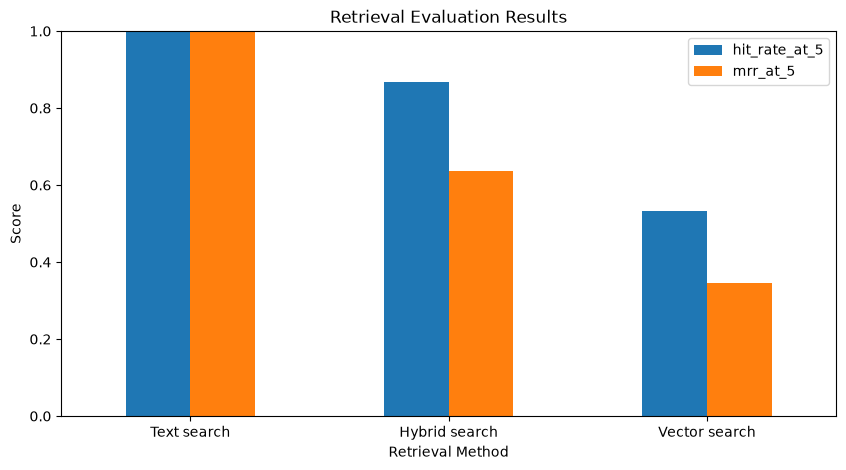

In [60]:
import matplotlib.pyplot as plt

chart_data = retrieval_summary.set_index(
    "retrieval_method"
)[
    [
        f"hit_rate_at_{TOP_K}",
        f"mrr_at_{TOP_K}",
    ]
]

chart_data.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("Retrieval Evaluation Results")
plt.ylabel("Score")
plt.xlabel("Retrieval Method")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

In [1]:
import pandas as pd

scores_path = "../data/evaluation/llm_prompt_scores.csv"

scores_df = pd.read_csv(scores_path)

score_columns = [
    "correct",
    "grounded",
    "has_citation",
    "clear",
]

for column in score_columns:
    scores_df[column] = pd.to_numeric(
        scores_df[column],
        errors="coerce",
    )

scores_df["total_score"] = scores_df[score_columns].sum(axis=1)

scores_df

,question,prompt,correct,grounded,has_citation,clear,notes,total_score
0,What is the electric driving range of the 2027...,basic,1,1,0,1,"Correct answer, but no source citation.",3
1,What is the electric driving range of the 2027...,grounded,1,1,1,1,Correct answer with source citation.,4
2,What is the combined MPGe efficiency of the 20...,basic,1,1,0,1,"Correct answer, but no source citation.",3
3,What is the combined MPGe efficiency of the 20...,grounded,1,1,1,1,Correct answer with source citation.,4
4,What is the 240V charging time for the 2026 Ro...,basic,1,1,0,1,"Correct answer, but no source citation.",3
5,What is the 240V charging time for the 2026 Ro...,grounded,1,1,1,1,Correct answer with source citation.,4
6,What is the electric driving range of the 2024...,basic,1,1,0,1,"Correct answer, but no source citation.",3
7,What is the electric driving range of the 2024...,grounded,1,1,1,1,Correct answer with source citation.,4
8,What is the combined MPGe efficiency of the 20...,basic,0,1,0,1,Answers with a 2025 BMW instead of the request...,2
9,What is the combined MPGe efficiency of the 20...,grounded,1,1,1,1,Correctly explains that the requested 2026 veh...,4


In [2]:
prompt_summary = (
    scores_df
    .groupby("prompt")["total_score"]
    .mean()
    .reset_index()
)

prompt_summary

,prompt,total_score
0,basic,2.8
1,grounded,4.0
